In [2]:
import matplotlib.pyplot as plt
import numpy as np
import joblib
import torch
from torch.utils.data import TensorDataset
from torch import nn

from net_utils import load_from_file
import plotting
import networks
from networks import HebbFeatureLayer
import importlib
import os


In [16]:
for netFile, imgsFile, label in [
        ('publish/conv/HebbNet[50,16,1]_train=cur1_incr=plus1_w1init=randn_b1init=scalar_w2init=scalar.pkl',
                           'publish\conv\BradyOliva2008_UniqueObjects_ResNet18.pkl', 'featurize'),
]:

    folder, filename = os.path.split(netFile)
    idx = filename.find('[')
    if idx == -1:
        idx = filename.find('_')
    if idx == -1:
         raise ValueError('Invalid filename')  
    NetClass = getattr(importlib.import_module('networks'), filename[:idx])
    print(NetClass)   

    net = load_from_file(netFile)
    N,d = net.w1.shape
    print(net.hist['increment_R'][-1][1])
    x = torch.randn(10, d)
    check = net.featurizer(x).detach()



<class 'networks.HebbNet'>
17


AttributeError: 'HebbNet' object has no attribute 'featurizer'

### Plot generalization after training done

R=1, truePos=1.000, falsePos=0.381, acc=0.735=0.735, (chance=0.695)
R=2, truePos=1.000, falsePos=0.346, acc=0.790=0.775, (chance=0.650)
R=3, truePos=1.000, falsePos=0.326, acc=0.770=0.770, (chance=0.705)
R=4, truePos=1.000, falsePos=0.348, acc=0.775=0.765, (chance=0.675)
R=6, truePos=1.000, falsePos=0.390, acc=0.755=0.735, (chance=0.680)
R=8, truePos=0.898, falsePos=0.390, acc=0.705=0.695, (chance=0.705)
R=11, truePos=0.833, falsePos=0.444, acc=0.664=0.655, (chance=0.645)
R=15, truePos=0.663, falsePos=0.462, acc=0.583=0.577, (chance=0.693)
R=20, truePos=0.646, falsePos=0.441, acc=0.587=0.587, (chance=0.675)
R=26, truePos=0.554, falsePos=0.496, acc=0.523=0.521, (chance=0.663)
R=34, truePos=0.534, falsePos=0.479, acc=0.532=0.525, (chance=0.672)
R=45, truePos=0.496, falsePos=0.497, acc=0.503=0.501, (chance=0.687)


(<Figure size 432x288 with 2 Axes>,
 array([<Axes: ylabel='Accuracy'>,
        <Axes: xlabel='$R_{test}$', ylabel='Probability'>], dtype=object))

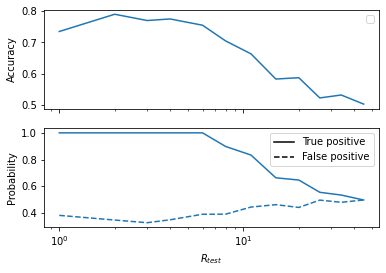

In [5]:
from networks import HebbFeatureLayer
from data import GenRecogClassifyData
from plotting import plot_generalization, get_recog_positive_rates

Nx = 512  # Raw image feature dimension (from ResNet output)
d = 128    # Compressed feature dimension
Nh = 32   # Hidden Hebbian layer size
Ny = 1    # Output dimension (recognition task)

Tmul = 20
Tmin = 200
P = 0.5 # Probability of repeat
noMultiRep = True

net = HebbFeatureLayer(init=[d, Nh, Ny], Nx=Nx)
pretrained_weights = "results/tensor_board_logs_no_freeze_augment_rutis/results/HebbFeature_no_freeze_augment_rutis_(4).pkl"
net.load(pretrained_weights)
img_dataset = "publish/conv/BradyOliva2008_UniqueObjects_ResNet18.pkl"
images = torch.load(img_dataset)
dummyClasses = torch.zeros(images.shape[0],1)
sampleSpace = TensorDataset(images, dummyClasses)
generator = GenRecogClassifyData(sampleSpace=sampleSpace)
    
def generate_recog_data_batch(T,d,R,P,multiRep,batchSize,**kwargs):
    x,y = generator(T, R, P, batchSize, multiRep).tensors
    return TensorDataset(x, y[..., 0:1])

if type(net) == HebbFeatureLayer:
    assert images.shape[1] == Nx # sanity check

gen_data = lambda R: generate_recog_data_batch(T=max(Tmin, R*Tmul), 
                                                   d=d, 
                                                   R=R, 
                                                   P=P, 
                                                   softLabels=False,
                                                   interleave=True, 
                                                   multiRep=(not noMultiRep), 
                                                   batchSize=None,
                                                   xDataVals='+-',
                                                   device='cpu')

testR, testAcc, truePosRate, falsePosRate = get_recog_positive_rates(net, gen_data)
plot_generalization(testR, testAcc, truePosRate, falsePosRate)

plot_loss_acc skipped: 'valid_loss'


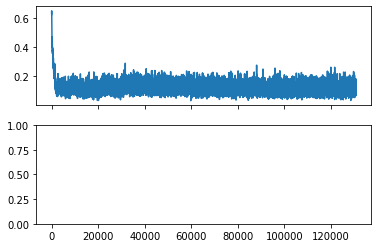

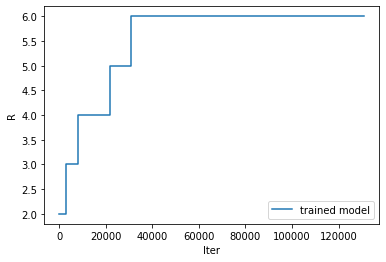

R=1, truePos=1.000, falsePos=0.008, acc=0.995=0.995, (chance=0.650)
R=2, truePos=1.000, falsePos=0.000, acc=1.000=1.000, (chance=0.690)
R=3, truePos=1.000, falsePos=0.000, acc=1.000=1.000, (chance=0.665)
R=4, truePos=1.000, falsePos=0.008, acc=0.995=0.995, (chance=0.640)
R=6, truePos=1.000, falsePos=0.029, acc=0.980=0.980, (chance=0.680)
R=8, truePos=0.984, falsePos=0.022, acc=0.985=0.980, (chance=0.690)
R=11, truePos=0.915, falsePos=0.020, acc=0.968=0.959, (chance=0.677)
R=15, truePos=0.578, falsePos=0.029, acc=0.853=0.853, (chance=0.700)
R=20, truePos=0.197, falsePos=0.033, acc=0.730=0.723, (chance=0.682)
R=26, truePos=0.090, falsePos=0.065, acc=0.665=0.665, (chance=0.681)
R=34, truePos=0.083, falsePos=0.044, acc=0.663=0.662, (chance=0.663)
R=45, truePos=0.072, falsePos=0.051, acc=0.664=0.663, (chance=0.674)
R=59, truePos=0.060, falsePos=0.045, acc=0.664=0.664, (chance=0.675)
R=77, truePos=0.037, falsePos=0.055, acc=0.658=0.658, (chance=0.684)


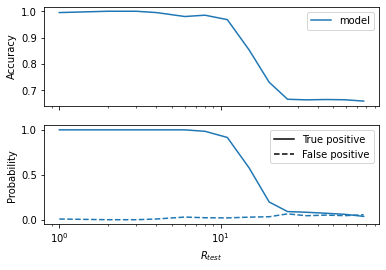

Plot distr R=1
Plot distr R=4
Plot distr R=21
Plot distr R=100


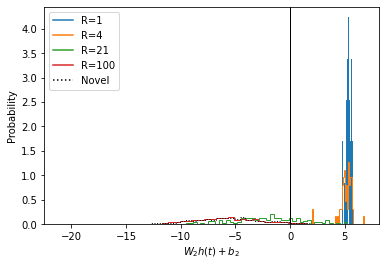

Plot RT R=1
Loading analysis_tmp_eval_R=1.pkl
Plot RT R=2
Plot RT R=4
Loading analysis_tmp_eval_R=4.pkl
Plot RT R=7
Plot RT R=12
Plot RT R=21
Loading analysis_tmp_eval_R=21.pkl
Plot RT R=35
Plot RT R=59
Plot RT R=100
Loading analysis_tmp_eval_R=100.pkl


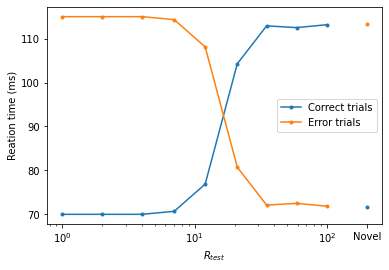

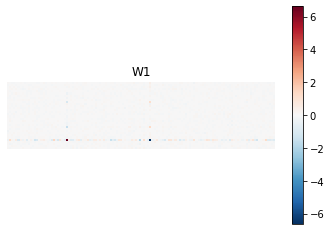

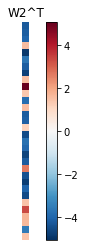

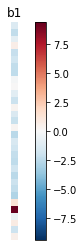

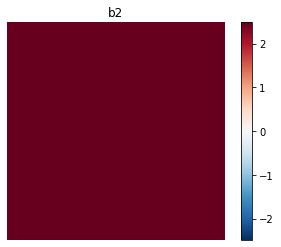

In [ ]:
import plotting

# -------------------------
# 1) Load trained model
# -------------------------
# ckpt = "results/tensor_board_logs_no_freeze_augment_brady/results/HebbFeature_no_freeze_augment_brady_(10).pkl"  # change
ckpt = "results/tensor_board_logs_no_freeze_augment_rutis/results/HebbFeature_no_freeze_augment_rutis_(6).pkl"

Nx = 512  # Raw image feature dimension (from ResNet output)
d = 128    # Compressed feature dimension
Nh = 32   # Hidden Hebbian layer size
Ny = 1    # Output dimension (recognition task)

net = HebbFeatureLayer(init=[d, Nh, Ny], Nx=Nx)
pretrained_weights = "results/tensor_board_logs_no_freeze_augment_rutis/results/HebbFeature_no_freeze_augment_rutis_(6).pkl"
net.load(pretrained_weights)

# -------------------------
# 2) Build gen_data(R)
# Choose ONE of the two options below
# -------------------------

# Option B: embeddings dataset (for HebbFeatureLayer with Nx-dim inputs)
def make_gen_data_embeddings(emb_path, Tmul=20, Tmin=200, P=0.5, multiRep=False):
    x = torch.load(emb_path)  # shape [N, Nx]
    y_dummy = torch.zeros(x.shape[0], 1)
    sample_space = TensorDataset(x, y_dummy)
    generator = GenRecogClassifyData(sampleSpace=sample_space)

    def gen_data(R):
        T = max(Tmin, int(R) * Tmul)
        xb, yb = generator(T=T, R=R, P=P, batchSize=None, multiRep=multiRep).tensors
        return TensorDataset(xb, yb[..., :1])  # recognition label only
    return gen_data

# pick one:
# gen_data = make_gen_data_synth(net)
gen_data = make_gen_data_embeddings("publish/conv/BradyOliva2008_UniqueObjects_ResNet18.pkl")

# -------------------------
# 3) Training curve (if available)
# -------------------------
try:
    plotting.plot_loss_acc(net)
    plt.show()
except Exception as e:
    print("plot_loss_acc skipped:", e)

# -------------------------
# 4) Curriculum trajectory R(iter)
# -------------------------
inc = net.hist.get("increment_R", [])
if len(inc) > 0:
    iters, Rs = map(list, zip(*inc))
    iters.append(net.hist.get("iter", iters[-1]))
    Rs.append(Rs[-1])
    plotting.plot_R_curriculum(iters, Rs, label="trained model")
    plt.legend()
    plt.show()
else:
    print("No increment_R found in net.hist")

# -------------------------
# 5) Generalization: acc, TP, FP vs R
# -------------------------
testR, testAcc, tp, fp = plotting.get_recog_positive_rates(
    net, gen_data, upToR=-float("inf"), stopAtR=300
)
ax = plotting.plot_generalization(testR, testAcc, tp, fp, label="model", xscale="log")
plt.show()

# -------------------------
# 6) Output/readout distributions over selected R
# -------------------------
Rs = np.unique(np.logspace(0, 2, 4, dtype=int))
plotting.plot_familiar_output_distr("analysis_tmp", gen_data, net=net, Rs=Rs, plotNov=True)
plt.show()

# -------------------------
# 7) Reaction-time-style curves
# -------------------------
plotting.plot_RT_curves("analysis_tmp", gen_data, Rs=np.unique(np.logspace(0, 2, 10, dtype=int)), net=net)
plt.show()

# -------------------------
# 8) Parameter heatmaps
# -------------------------
if hasattr(net, "w1"):
    plotting.plot_weight(net.w1.detach()); plt.title("W1"); plt.show()
if hasattr(net, "w2"):
    W2 = net.w2.detach().t() if net.w2.ndim == 2 else net.w2.detach().unsqueeze(1)
    plotting.plot_weight(W2); plt.title("W2^T"); plt.show()
if hasattr(net, "b1"):
    plotting.plot_weight(net.b1.detach().unsqueeze(1)); plt.title("b1"); plt.show()
if hasattr(net, "b2"):
    plotting.plot_weight(net.b2.detach().unsqueeze(1)); plt.title("b2"); plt.show()

### Check training logs

In [7]:
d = 50
Nh = 16
Ny = 1
Nx = 512

pkl_path = "results/tensor_board_logs_no_freeze/results/HebbFeature_no_freeze_(6).pkl"
net = HebbFeatureLayer(init=[d, Nh, Ny], Nx=Nx)
net.load(pkl_path)

# Inspect available history keys
print("hist keys:", list(net.hist.keys()))

# Expected format: net.hist["increment_R"] = [(iteration_idx, R_value), ...]
inc = net.hist.get("increment_R", None)
if inc is None or len(inc) == 0:
    raise ValueError("No 'increment_R' history found in this checkpoint.")

# Try to infer total number of training iterations
total_iters = None
for k in ["train_acc", "train_loss", "iters", "iter"]:
    if k in net.hist:
        try:
            total_iters = len(net.hist[k])
            break
        except TypeError:
            pass

if total_iters is None:
    # Fallback: use last recorded increment iteration as total boundary
    total_iters = int(inc[-1][0])

print(f"Total iterations (estimated): {total_iters}")
print("\nIterations trained per R:")

# Compute durations per R from increment points
# Each entry means: at iteration `it`, R becomes `Rval`
for i, (start_it, Rval) in enumerate(inc):
    end_it = inc[i + 1][0] if i + 1 < len(inc) else total_iters
    n_iters = int(end_it - start_it)
    print(f"R={Rval}: {n_iters} iterations (from {start_it} to {end_it})")

hist keys: ['epoch', 'iter', 'train_loss', 'train_acc', 'grad_norm', 'increment_R']
Total iterations (estimated): 4088

Iterations trained per R:
R=2: 4370 iterations (from 0 to 4370)
R=3: 2870 iterations (from 4370 to 7240)
R=4: 3660 iterations (from 7240 to 10900)
R=5: 7520 iterations (from 10900 to 18420)
R=6: 7170 iterations (from 18420 to 25590)
R=7: 15280 iterations (from 25590 to 40870)
R=8: -36782 iterations (from 40870 to 4088)


### Tests for augmented embeddings

Total images found: 596
R=1, truePos=1.000, falsePos=0.030, acc=0.980=0.980, (chance=0.670)
R=2, truePos=0.984, falsePos=0.014, acc=0.985=0.985, (chance=0.695)
R=3, truePos=0.969, falsePos=0.066, acc=0.950=0.945, (chance=0.680)
R=4, truePos=0.933, falsePos=0.036, acc=0.960=0.955, (chance=0.700)
R=6, truePos=0.765, falsePos=0.023, acc=0.905=0.905, (chance=0.660)
R=8, truePos=0.508, falsePos=0.028, acc=0.840=0.835, (chance=0.705)
R=11, truePos=0.304, falsePos=0.060, acc=0.741=0.741, (chance=0.686)
R=15, truePos=0.110, falsePos=0.040, acc=0.683=0.677, (chance=0.667)
R=20, truePos=0.121, falsePos=0.076, acc=0.680=0.675, (chance=0.690)
R=26, truePos=0.061, falsePos=0.073, acc=0.656=0.656, (chance=0.687)


/home/raaghav/hebbff/plotting.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


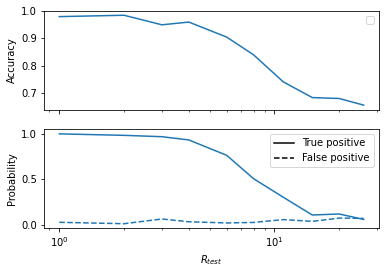

In [ ]:
from data import GenRecogClassifyData_AD_Precompute
import math

IMAGE_DIR = "/home/raaghav/hebbff/Images/Stimuli"
save_fig_file = "results/gen_plot_feature_and_hebbff_augment_rutis.png"
base_bank = "precomputed_embeddings/base_bank/rutis_base.npy"
aug_bank = "precomputed_embeddings/aug_bank/rutis_aug.npy"


# Parameters
Nx = 512  # Raw image feature dimension (from ResNet output)
d = 128    # Compressed feature dimension
Nh = 32   # Hidden Hebbian layer size
Ny = 1    # Output dimension (recognition task)

# Train parameters
pretrained = "/home/raaghav/hebbff/results/tensor_board_logs_no_freeze_augment_rutis/results/HebbFeature_no_freeze_augment_rutis_(4).pkl"
Tmul = 20
Tmin = 200
P = 0.5 # Probability of repeat
P2 = 0 # Always do augmentation
noMultiRep = True
increment = 'plus1'
R0 = 2
Rf = float('inf') # No upper limit on R during training
# itersToQuit = 2*10**6
itersToQuit = 20000
accuracyStopThres = 4.9 # Stop training if average accuracy over last 5 epochs exceeds this threshold

net = HebbFeatureLayer(init=[d, Nh, Ny], Nx=Nx)
net.load(pretrained)

images_paths = []
for root, dirs, files in os.walk(IMAGE_DIR):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            images_paths.append(os.path.join(root, file))

print(f"Total images found: {len(images_paths)}")

generator = GenRecogClassifyData_AD_Precompute(image_paths=images_paths, device="cpu", base_bank_npy=base_bank, aug_bank_npy=aug_bank)
    
def generate_recog_data_batch(T,d,R,P,P2,multiRep,batchSize,**kwargs):
    x,y = generator(T, R, P, P2, batchSize, multiRep).tensors
    return TensorDataset(x, y[..., 0:1])

gen_data = lambda R: generate_recog_data_batch(T=min(max(Tmin, R*Tmul), len(images_paths)), 
                                                   d=d, 
                                                   R=R, 
                                                   P=P, 
                                                   P2=P2,
                                                   softLabels=False,
                                                   interleave=True, 
                                                   multiRep=(not noMultiRep), 
                                                   batchSize=None,
                                                   xDataVals='+-')
if increment.startswith('plus'):
    n = int(increment[4:])
    increment = lambda R: R+n
elif increment.startswith('times'):
    n = float(increment[5:])
    increment = lambda R: int(math.ceil(R*n)) 
    
testR, testAcc, truePosRate, falsePosRate = get_recog_positive_rates(net, gen_data)
fig, ax = plot_generalization(testR, testAcc, truePosRate, falsePosRate)
fig.savefig(save_fig_file, dpi=200, bbox_inches="tight")

plot_loss_acc skipped: 'valid_loss'


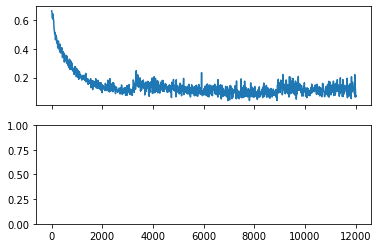

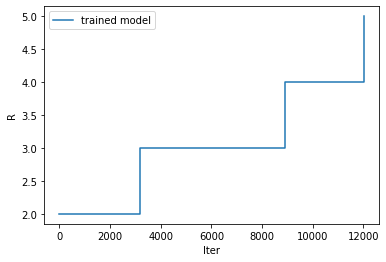

Plot distr R=1
Loading analysis_tmp_eval_R=1.pkl
Plot distr R=4
Loading analysis_tmp_eval_R=4.pkl
Plot distr R=21
Loading analysis_tmp_eval_R=21.pkl
Plot distr R=100
Loading analysis_tmp_eval_R=100.pkl


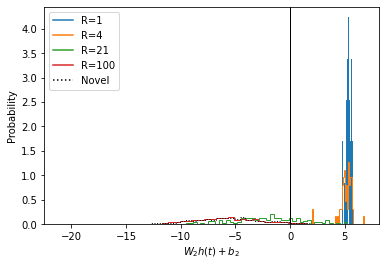

Plot RT R=1
Loading analysis_tmp_eval_R=1.pkl
Plot RT R=2
Loading analysis_tmp_eval_R=2.pkl
Plot RT R=4
Loading analysis_tmp_eval_R=4.pkl
Plot RT R=7
Loading analysis_tmp_eval_R=7.pkl
Plot RT R=12
Loading analysis_tmp_eval_R=12.pkl
Plot RT R=21
Loading analysis_tmp_eval_R=21.pkl
Plot RT R=35
Loading analysis_tmp_eval_R=35.pkl
Plot RT R=59
Loading analysis_tmp_eval_R=59.pkl
Plot RT R=100
Loading analysis_tmp_eval_R=100.pkl


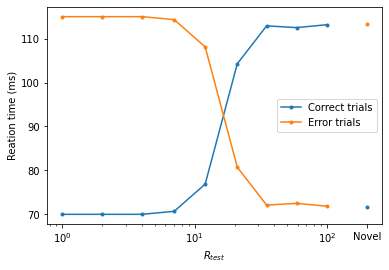

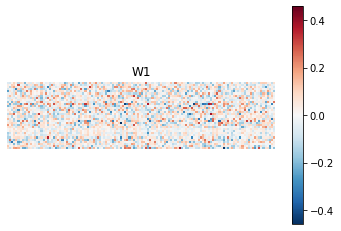

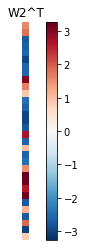

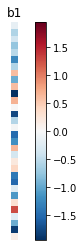

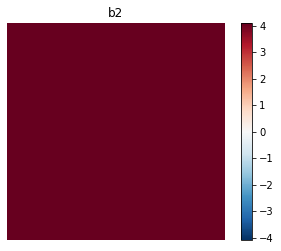

In [10]:
import plotting

# -------------------------
# 1) Load trained model
# -------------------------
# ckpt = "results/tensor_board_logs_no_freeze_augment_brady/results/HebbFeature_no_freeze_augment_brady_(10).pkl"  # change
ckpt = "results/tensor_board_logs_no_freeze_augment_rutis/results/HebbFeature_no_freeze_augment_rutis_(4).pkl"

Nx = 512  # Raw image feature dimension (from ResNet output)
d = 128    # Compressed feature dimension
Nh = 32   # Hidden Hebbian layer size
Ny = 1    # Output dimension (recognition task)

net = HebbFeatureLayer(init=[d, Nh, Ny], Nx=Nx)
pretrained_weights = "results/tensor_board_logs_no_freeze_augment_rutis/results/HebbFeature_no_freeze_augment_rutis_(4).pkl"
net.load(pretrained_weights)

generator = GenRecogClassifyData_AD_Precompute(image_paths=images_paths, device="cpu", base_bank_npy=base_bank, aug_bank_npy=aug_bank)
    
def generate_recog_data_batch(T,d,R,P,P2,multiRep,batchSize,**kwargs):
    x,y = generator(T, R, P, P2, batchSize, multiRep).tensors
    return TensorDataset(x, y[..., 0:1])

gen_data = lambda R: generate_recog_data_batch(T=min(max(Tmin, R*Tmul), len(images_paths)), 
                                                   d=d, 
                                                   R=R, 
                                                   P=P, 
                                                   P2=P2,
                                                   softLabels=False,
                                                   interleave=True, 
                                                   multiRep=(not noMultiRep), 
                                                   batchSize=None,
                                                   xDataVals='+-')


# -------------------------
# 3) Training curve (if available)
# -------------------------
try:
    plotting.plot_loss_acc(net)
    plt.show()
except Exception as e:
    print("plot_loss_acc skipped:", e)

# -------------------------
# 4) Curriculum trajectory R(iter)
# -------------------------
inc = net.hist.get("increment_R", [])
if len(inc) > 0:
    iters, Rs = map(list, zip(*inc))
    iters.append(net.hist.get("iter", iters[-1]))
    Rs.append(Rs[-1])
    plotting.plot_R_curriculum(iters, Rs, label="trained model")
    plt.legend()
    plt.show()
else:
    print("No increment_R found in net.hist")

# -------------------------
# 6) Output/readout distributions over selected R
# -------------------------
Rs = np.unique(np.logspace(0, 2, 4, dtype=int))
plotting.plot_familiar_output_distr("analysis_tmp", gen_data, net=net, Rs=Rs, plotNov=True)
plt.show()

# -------------------------
# 7) Reaction-time-style curves
# -------------------------
plotting.plot_RT_curves("analysis_tmp", gen_data, Rs=np.unique(np.logspace(0, 2, 10, dtype=int)), net=net)
plt.show()

# -------------------------
# 8) Parameter heatmaps
# -------------------------
if hasattr(net, "w1"):
    plotting.plot_weight(net.w1.detach()); plt.title("W1"); plt.show()
if hasattr(net, "w2"):
    W2 = net.w2.detach().t() if net.w2.ndim == 2 else net.w2.detach().unsqueeze(1)
    plotting.plot_weight(W2); plt.title("W2^T"); plt.show()
if hasattr(net, "b1"):
    plotting.plot_weight(net.b1.detach().unsqueeze(1)); plt.title("b1"); plt.show()
if hasattr(net, "b2"):
    plotting.plot_weight(net.b2.detach().unsqueeze(1)); plt.title("b2"); plt.show()

In [ ]:
from data import GenRecogClassifyData
from pathlib import Path

embeddings_dir = "Embeddings"   # change if needed
n_sequences_per_R = 200         # "a lot" of evaluation sequences
Rs_eval = np.unique(np.logspace(0, 2, 8, dtype=int))  # [1 ... 100], log-spaced

def load_experiment(experiment_dir):
	experiment_dir = Path(experiment_dir)
	class_dirs = sorted([p for p in experiment_dir.iterdir() if p.is_dir()])
	if len(class_dirs) == 0:
		raise ValueError(f"No category subfolders found in {experiment_dir}")

	x_list = []
	y_list = []
	class_names = []
	class_counts = {}

	for class_idx, class_dir in enumerate(class_dirs):
		class_names.append(class_dir.name)
		npy_files = sorted(class_dir.glob("*.npy"))
		if len(npy_files) == 0:
			continue

		for npy_file in npy_files:
			vec = np.load(npy_file)
			vec = torch.as_tensor(vec, dtype=torch.float32).reshape(-1)
			x_list.append(vec)
			y_list.append(class_idx)

		class_counts[class_dir.name] = len(npy_files)

	if len(x_list) == 0:
		raise ValueError(f"No .npy files found under {experiment_dir}")

	x = torch.stack(x_list, dim=0)
	y = torch.tensor(y_list, dtype=torch.long)

	if x.shape[1] != 512:
		raise ValueError(f"Expected 512-d embeddings, got {tuple(x.shape)} for {experiment_dir}")

	return x, y, class_names, class_counts

all_x_chunks = []
all_y_chunks = []
all_class_names = []
all_class_counts = {}

root = Path(embeddings_dir)
experiments = sorted([p for p in root.iterdir() if p.is_dir()])

for exp_dir in experiments:
    x, y, class_names, class_counts = load_experiment(exp_dir)
    print(f"Experiment {exp_dir}: {x.shape}, {y.shape}, classes={class_names}, counts={class_counts}")
    label_offset = len(all_class_names)

    all_x_chunks.append(x)
    all_y_chunks.append(y + label_offset)

    prefixed_names = [f"{exp_dir}/{name}" for name in class_names]
    all_class_names.extend(prefixed_names)
    all_class_counts.update({f"{exp_dir}/{k}": v for k, v in class_counts.items()})

    all_x = torch.cat(all_x_chunks, dim=0)
    all_y = torch.cat(all_y_chunks, dim=0)
    class_names = all_class_names
    class_counts = all_class_counts
    
net.eval()
results = {}  # category -> {"per_R": {R: [accs]}, "all": [accs]}
device = next(net.parameters()).device

# Evaluate from aggregated tensors built above: all_x, all_y, class_names
with torch.no_grad():
    n_classes = len(class_names)

    for class_idx in range(n_classes):
        cat = class_names[class_idx]
        mask = (all_y == class_idx)
        if not torch.any(mask):
            continue

        x_cat = all_x[mask]
        y_dummy = torch.zeros(x_cat.shape[0], 1, dtype=torch.float32)
        print(x_cat.size)
        sample_space = TensorDataset(x_cat, y_dummy)
        gen = GenRecogClassifyData(sampleSpace=sample_space)

        per_R = {int(R): [] for R in Rs_eval}
        all_acc = []

        for R in Rs_eval:
            R = int(R)
            T = max(Tmin, R * Tmul)
            T = min(T, max(10, x_cat.shape[0]))  # cap by category pool size

            for _ in range(n_sequences_per_R):
                xb, yb = gen(T=T, R=R, P=P, batchSize=1, multiRep=(not noMultiRep)).tensors
                xb = xb.to(device)
                y_true = yb[..., :1].float().to(device)

                logits = net(xb)
                y_pred = (logits > 0).float()
                acc = (y_pred == y_true).float().mean().item()

                per_R[R].append(acc)
                all_acc.append(acc)

        results[cat] = {"per_R": per_R, "all": all_acc}

# Summary table
summary = []
for cat, dct in results.items():
    arr = np.array(dct["all"], dtype=float)
    summary.append((cat, arr.mean(), arr.var(ddof=1), arr.std(ddof=1), len(arr)))
summary = sorted(summary, key=lambda x: x[1], reverse=True)

print("Category accuracy summary (sorted by mean):")
print(f"{'Category':25s} {'Mean':>8s} {'Var':>10s} {'Std':>8s} {'N':>8s}")
for cat, mean_, var_, std_, n_ in summary:
    print(f"{cat:25s} {mean_:8.4f} {var_:10.6f} {std_:8.4f} {n_:8d}")

# Plot 1: mean ± std per category (overall)
cats = [s[0] for s in summary]
means = [s[1] for s in summary]
stds = [s[3] for s in summary]

plt.figure(figsize=(max(8, len(cats) * 0.8), 4))
plt.bar(cats, means, yerr=stds, capsize=4)
plt.ylabel("Accuracy")
plt.title("Category-wise accuracy (mean ± std)")
plt.ylim(0.0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot 2: per-R mean with variance bands for each category
plt.figure(figsize=(7, 5))
for cat, dct in results.items():
    rvals = sorted(dct["per_R"].keys())
    m = np.array([np.mean(dct["per_R"][r]) if len(dct["per_R"][r]) else np.nan for r in rvals], dtype=float)
    v = np.array([np.var(dct["per_R"][r], ddof=1) if len(dct["per_R"][r]) > 1 else 0.0 for r in rvals], dtype=float)
    s = np.sqrt(v)
    plt.plot(rvals, m, marker="o", label=cat)
    plt.fill_between(rvals, np.clip(m - s, 0, 1), np.clip(m + s, 0, 1), alpha=0.15)

plt.xscale("log")
plt.xlabel("R")
plt.ylabel("Accuracy")
plt.title("Accuracy vs R by category (shaded ±1 std)")
plt.ylim(0.0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Experiment Embeddings/newolddelay: torch.Size([215, 512]), torch.Size([215]), classes=['houses', 'landscapes', 'mobility', 'phones', 'smallAnimal', 'ztrain'], counts={'houses': 44, 'landscapes': 43, 'mobility': 40, 'phones': 40, 'smallAnimal': 42, 'ztrain': 6}
Experiment Embeddings/newolddelay2: torch.Size([156, 512]), torch.Size([156]), classes=['fruit', 'kids', 'military', 'space', 'zzanimal'], counts={'fruit': 31, 'kids': 30, 'military': 35, 'space': 30, 'zzanimal': 30}
Experiment Embeddings/newolddelay3: torch.Size([225, 512]), torch.Size([225]), classes=['1cars', '2food', '3people', '4spatial', '5animals'], counts={'1cars': 44, '2food': 44, '3people': 45, '4spatial': 45, '5animals': 47}


RuntimeError: vector + matrix @ vector expected, got 1, 2, 3